# Trabalho 3

## Técnica Baseada em Projecão Horizontal


[neg_4.png] Ângulo detectado: -4.00 graus


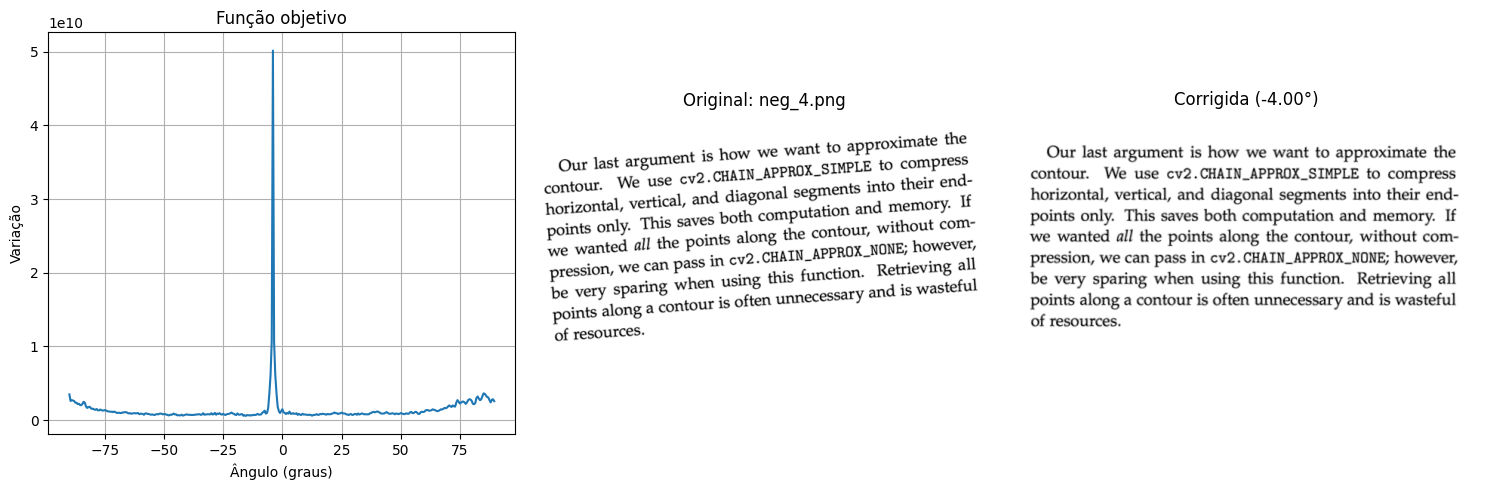

[neg_28.png] Ângulo detectado: -28.00 graus


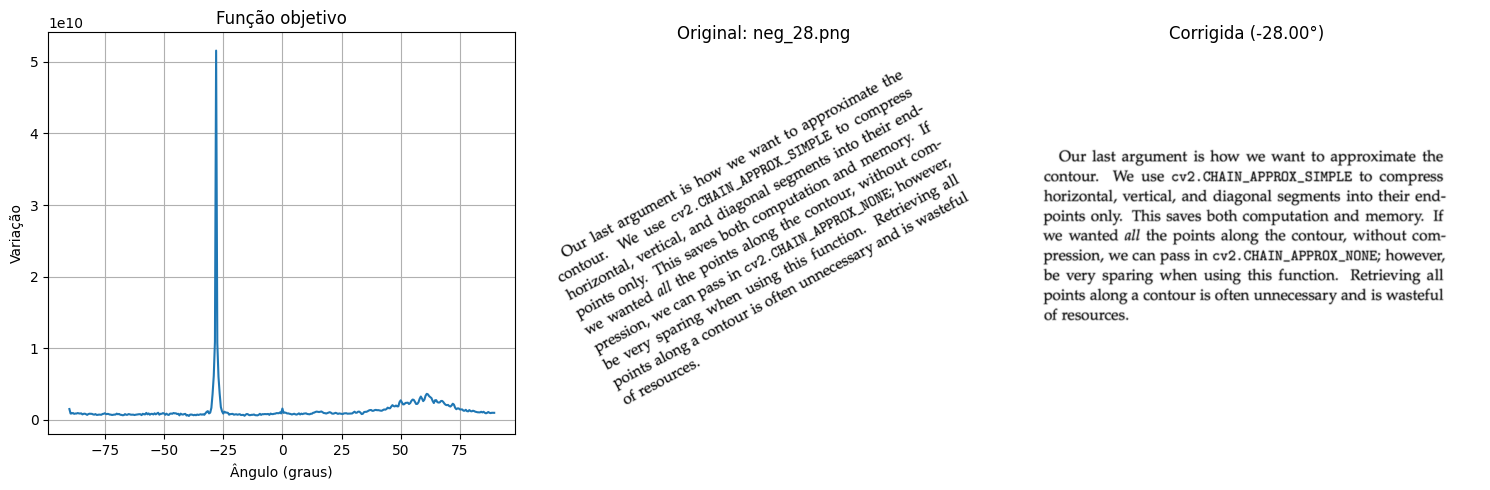

[partitura.png] Ângulo detectado: 25.50 graus


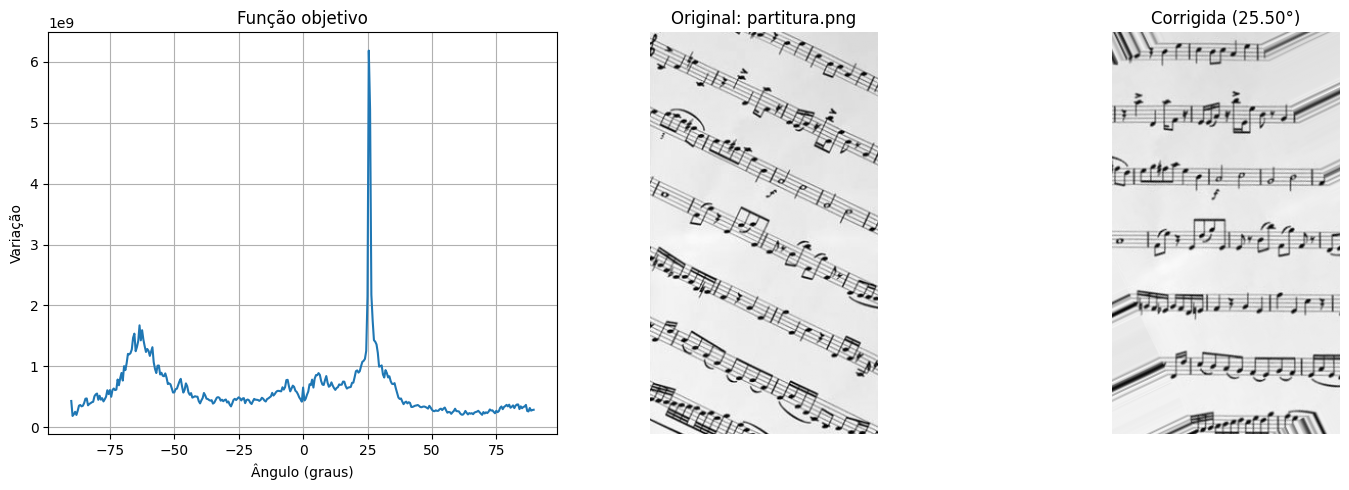

[pos_24.png] Ângulo detectado: 24.00 graus


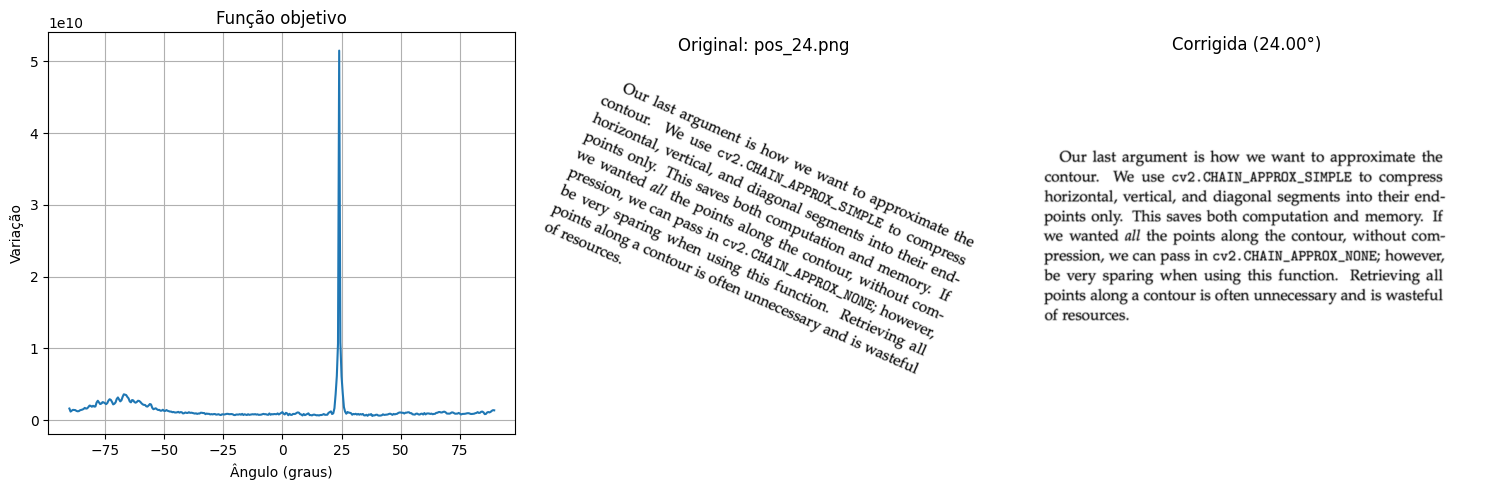

[pos_41.png] Ângulo detectado: 41.00 graus


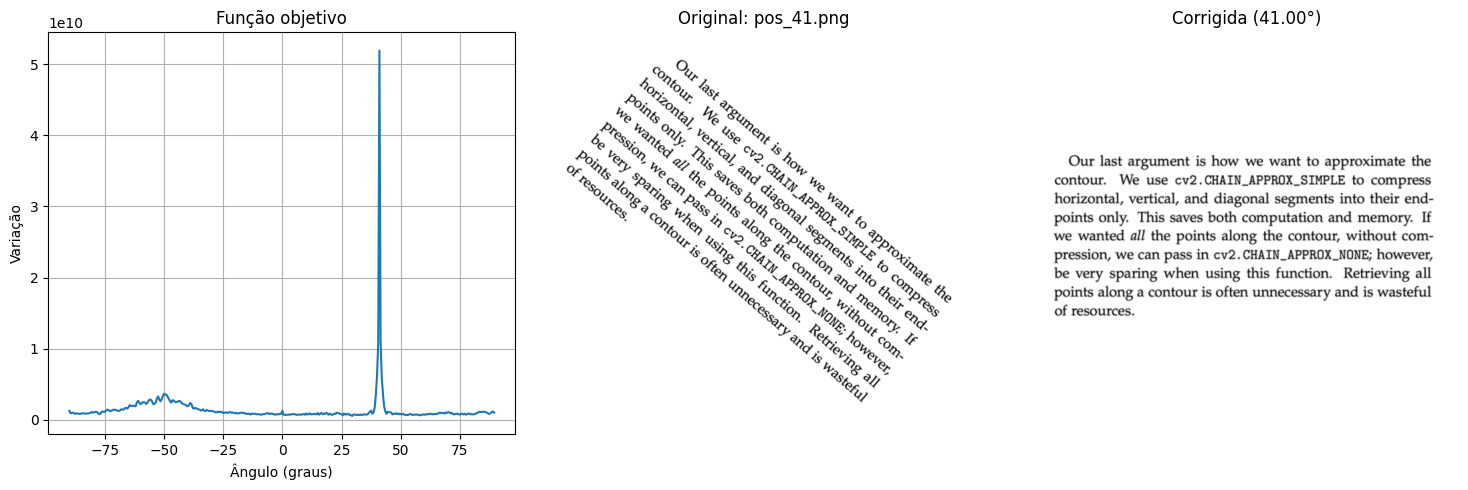

[sample1.png] Ângulo detectado: 14.00 graus


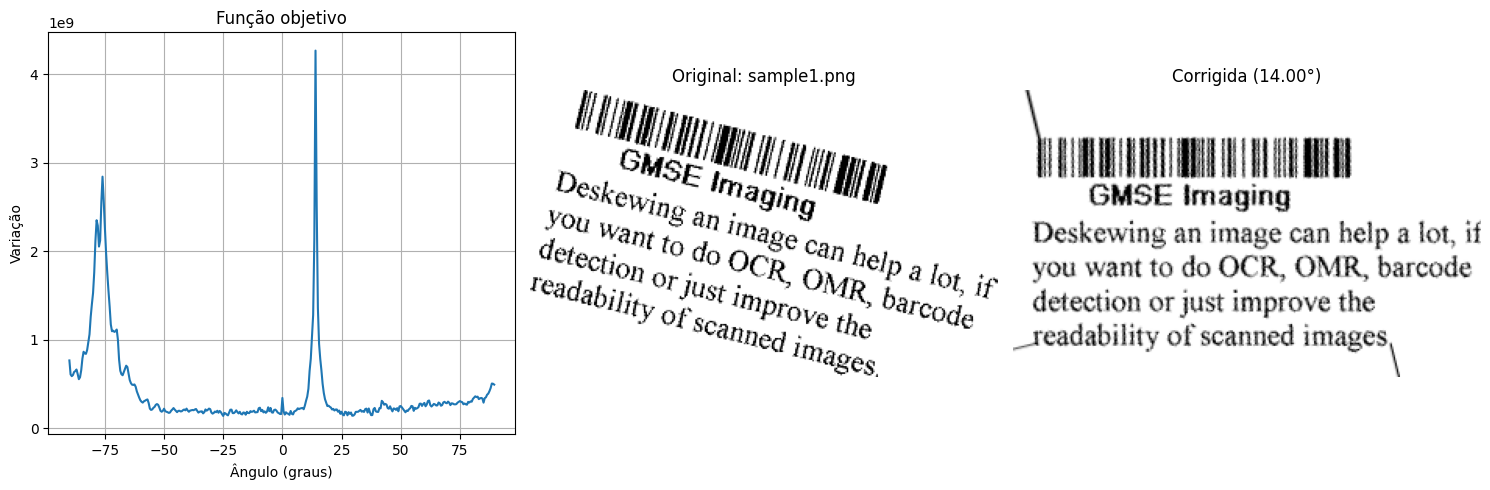

[sample2.png] Ângulo detectado: -6.00 graus


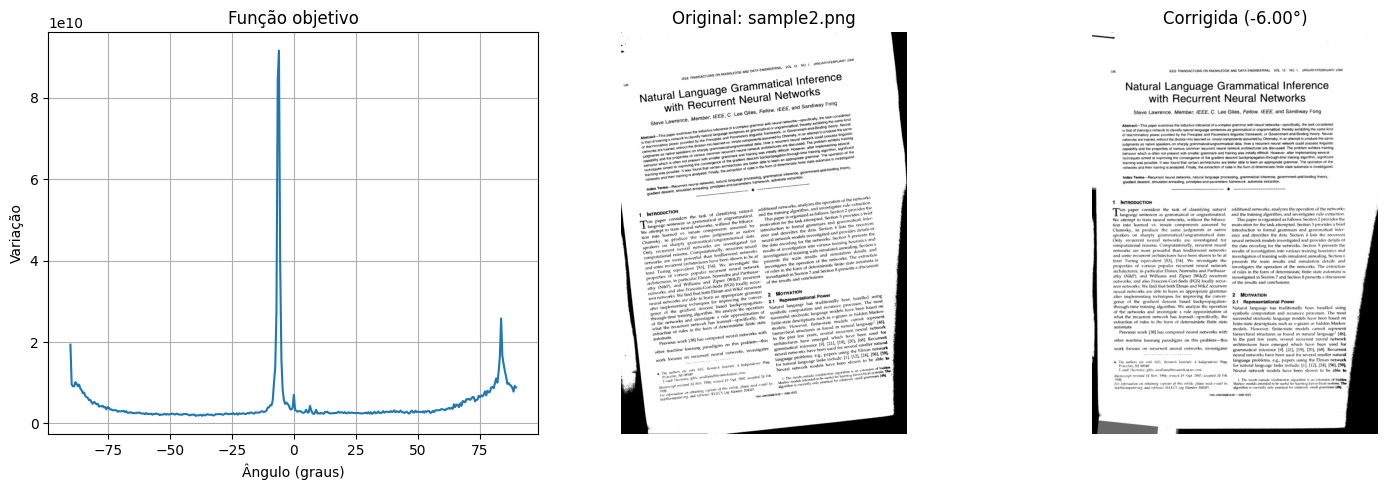

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import rotate
import os

def detectar_angulo_projecao_horizontal(imagem):
    _, binaria = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    melhor_angulo = 0
    melhor_valor = -1
    angulos_testados = np.arange(-90, 90, 0.5)
    variacoes = []

    for angulo in angulos_testados:
        rotacionada = rotate(binaria, angulo, resize=True, mode='edge', preserve_range=True).astype(np.uint8)
        perfil = np.sum(rotacionada, axis=1)
        variacao = np.sum(np.diff(perfil) ** 2)
        variacoes.append(variacao)

        if variacao > melhor_valor:
            melhor_valor = variacao
            melhor_angulo = angulo

    return melhor_angulo, angulos_testados, variacoes

def rotacionar(imagem, angulo):
    (h, w) = imagem.shape[:2]
    centro = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    return cv2.warpAffine(imagem, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

# Lista com os caminhos das imagens
imagens = [
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_4.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_28.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/partitura.png',
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_24.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_41.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/sample1.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/sample2.png'
]

for caminho in imagens:
    imagem = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    nome_arquivo = os.path.basename(caminho)

    angulo, angulos_testados, variacoes = detectar_angulo_projecao_horizontal(imagem)

    print(f"[{nome_arquivo}] Ângulo detectado: {angulo:.2f} graus")

    imagem_corrigida = rotacionar(imagem, angulo)

    # Figura com 3 subplots: variação, original, corrigida
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot da função objetivo
    axes[0].plot(angulos_testados, variacoes)
    axes[0].set_title("Função objetivo")
    axes[0].set_xlabel("Ângulo (graus)")
    axes[0].set_ylabel("Variação")
    axes[0].grid(True)

    # Imagem original
    axes[1].imshow(imagem, cmap='gray')
    axes[1].set_title(f"Original: {nome_arquivo}")
    axes[1].axis('off')

    # Imagem corrigida
    axes[2].imshow(imagem_corrigida, cmap='gray')
    axes[2].set_title(f"Corrigida ({angulo:.2f}°)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


## Hough


[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_4.png


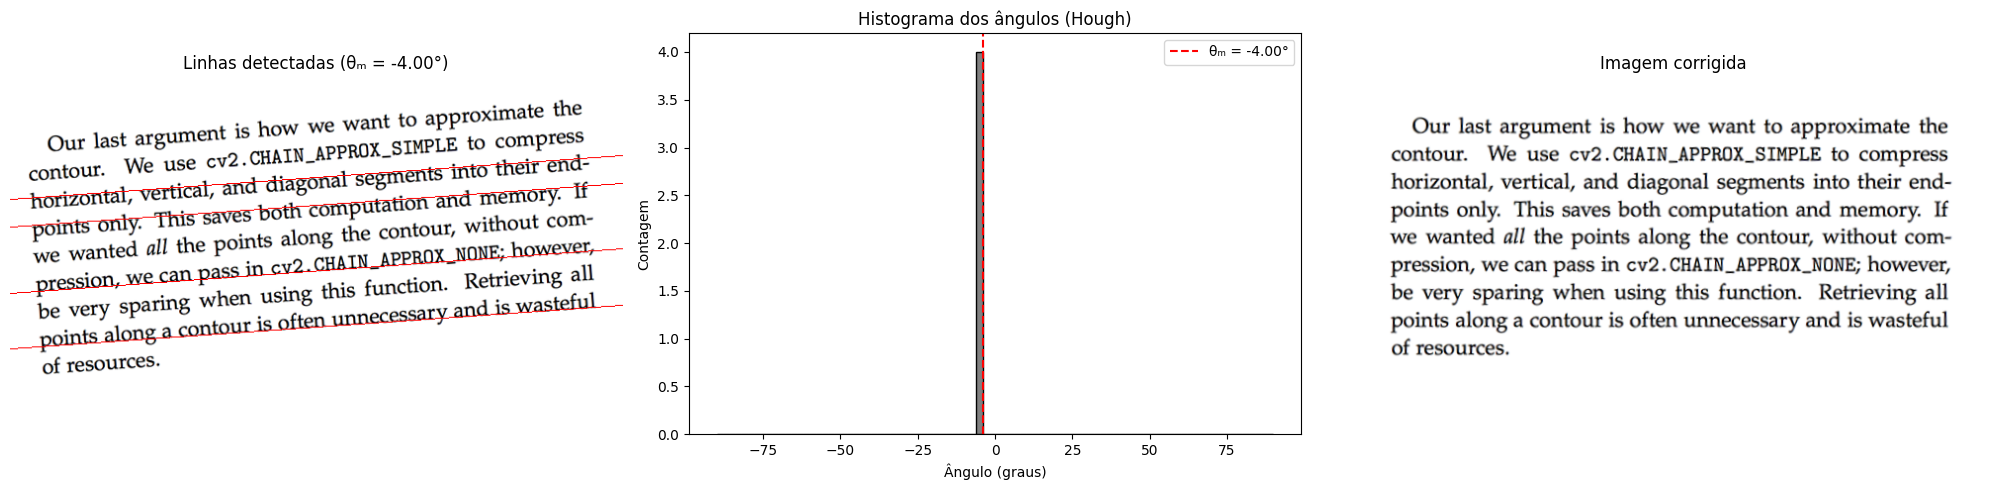

    Ângulo estimado: -4.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_28.png


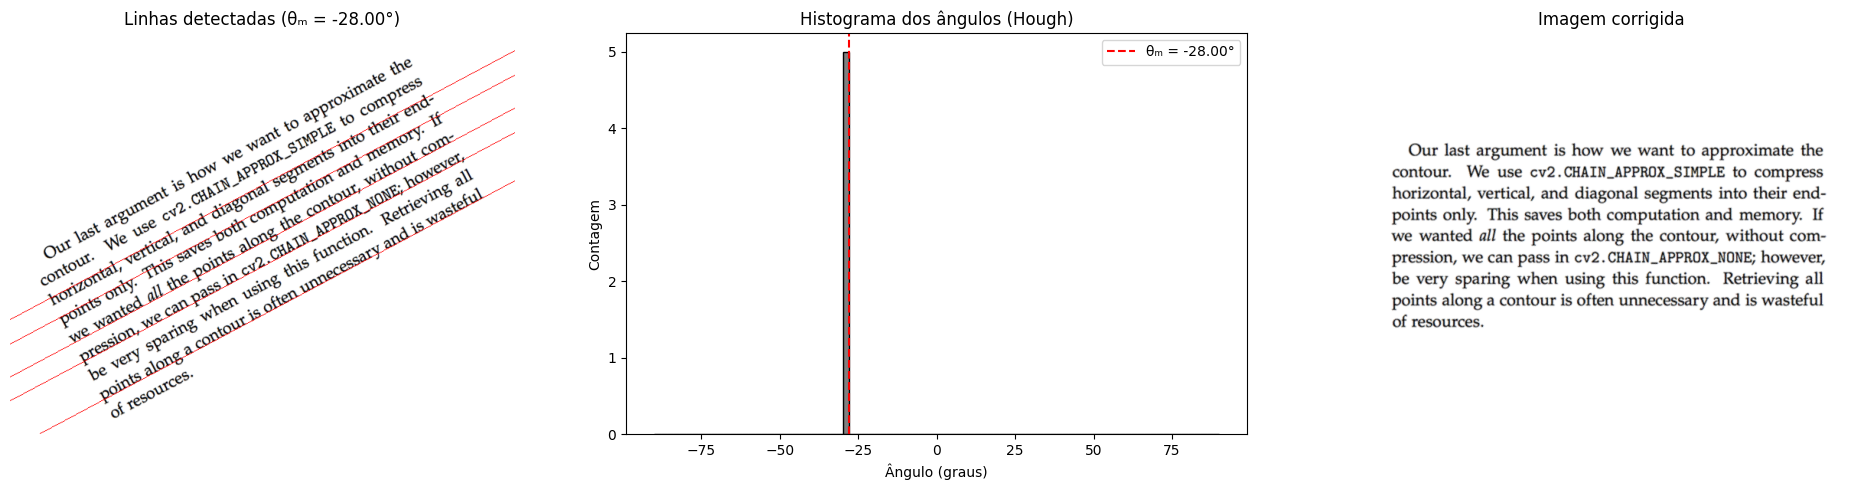

    Ângulo estimado: -28.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/partitura.png


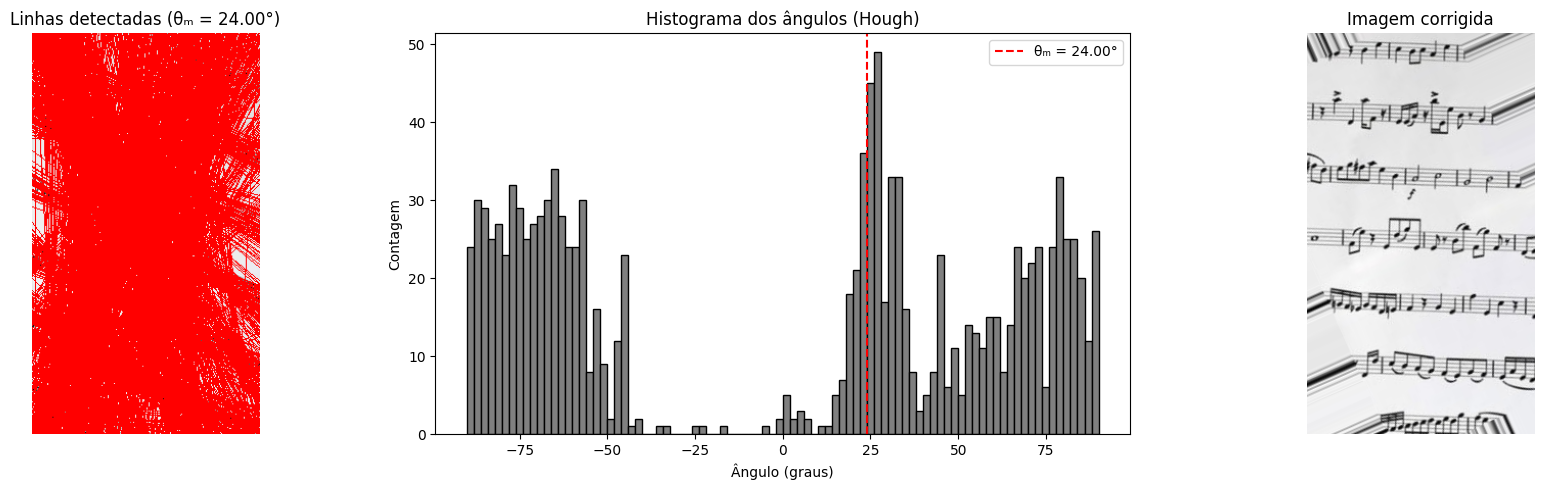

    Ângulo estimado: 24.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_24.png


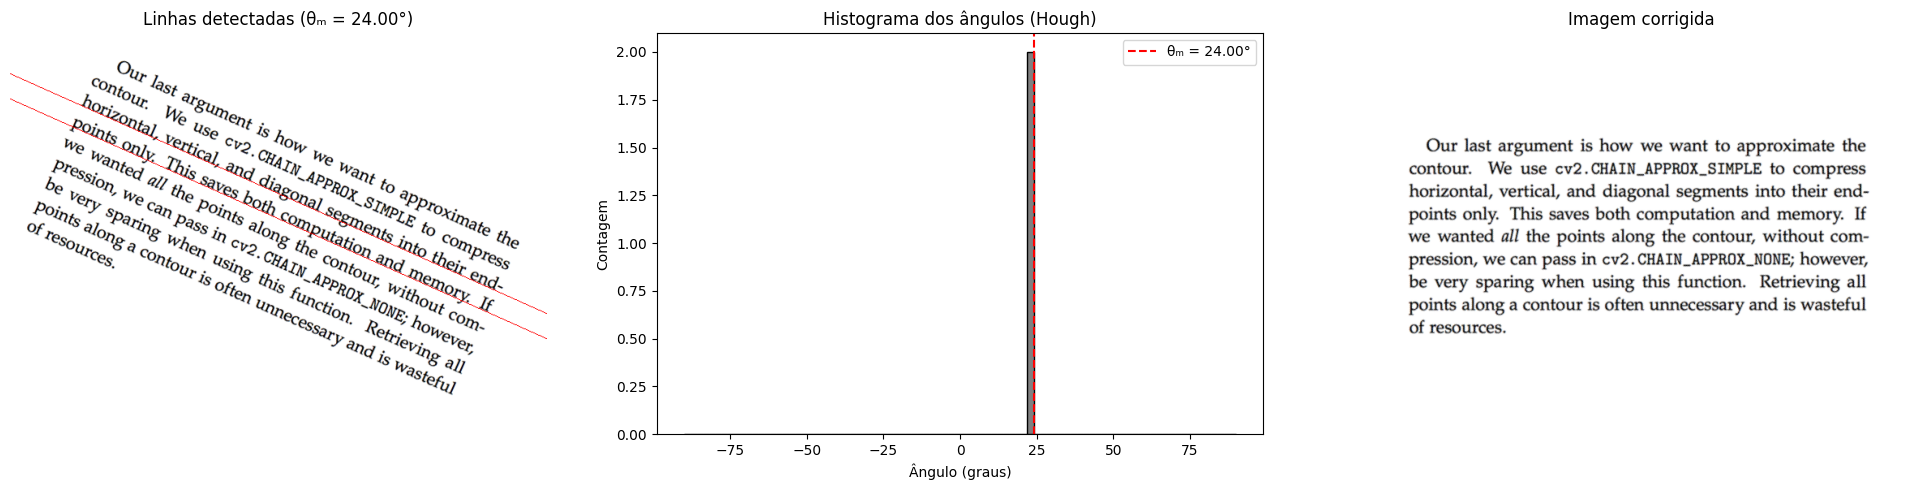

    Ângulo estimado: 24.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_41.png


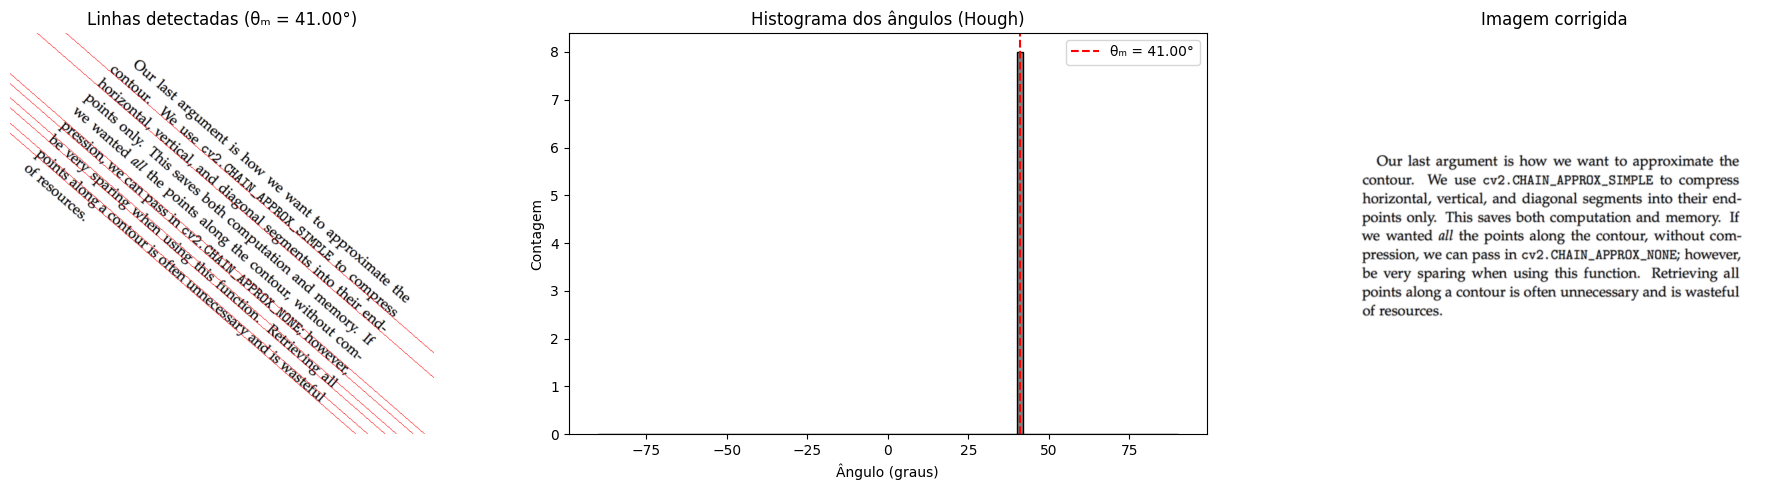

    Ângulo estimado: 41.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/sample1.png


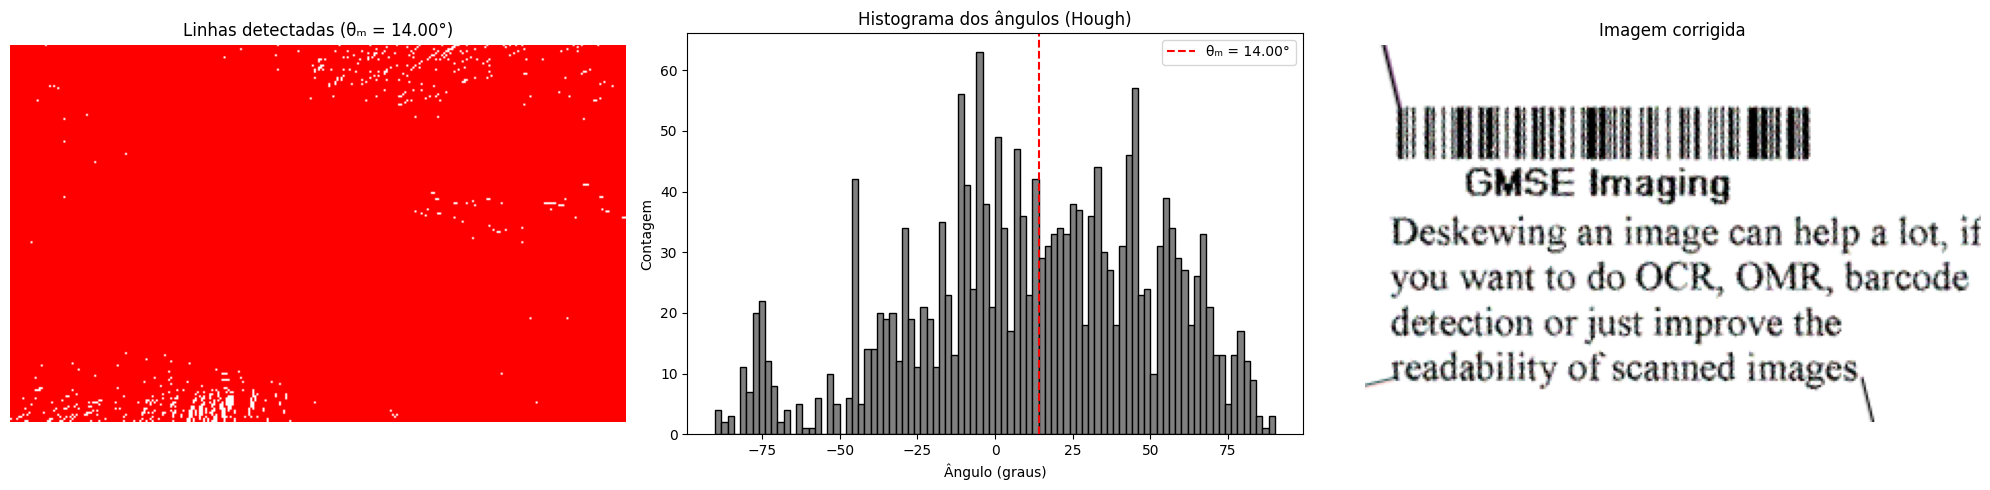

    Ângulo estimado: 14.00 graus

[+] Processando: /home/matheus-nicacio/Documentos/Trabalho - 3/image/sample2.png


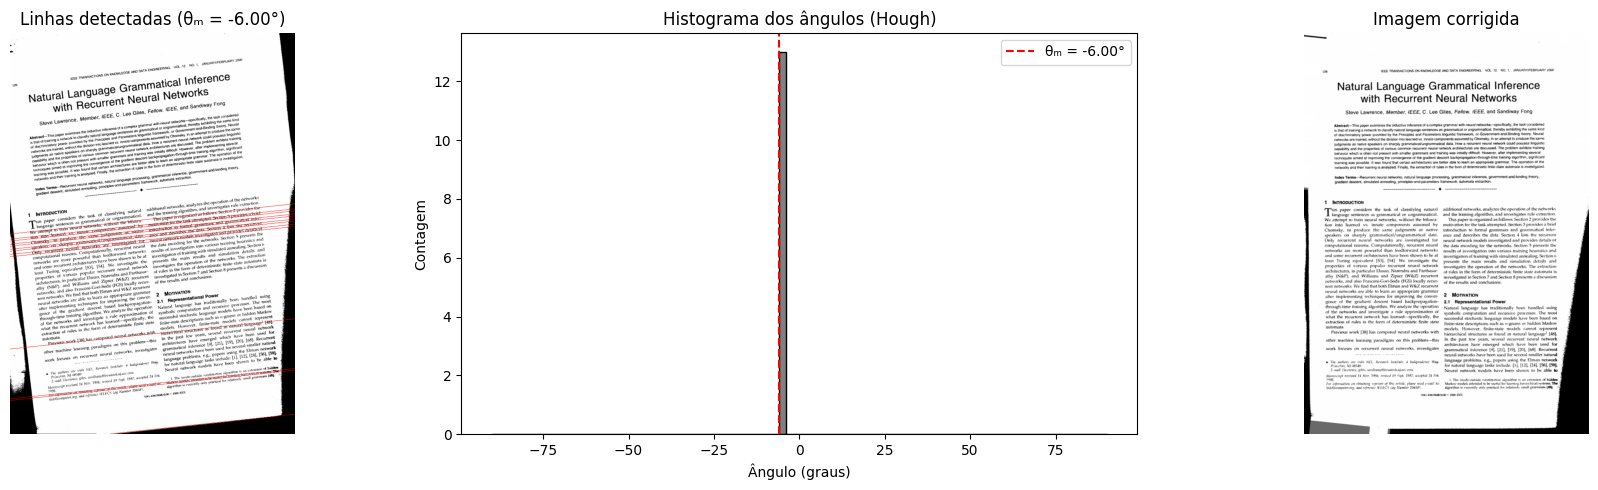

    Ângulo estimado: -6.00 graus


In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def detectar_angulo_hough_melhorado(imagem, exibir_resultado=False):
    # Conversão para escala de cinza
    cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

    # Equalização adaptativa do histograma para melhorar contraste
    clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8,8))
    equalizada = clahe.apply(cinza)

    # Suavização com filtro Gaussiano
    suave = cv2.GaussianBlur(equalizada, (5, 5), 0)

    # Canny automático com base na mediana da imagem
    v = np.median(suave)
    sigma = 0.33
    limiar_inferior = int(max(0, (1.0 - sigma) * v))
    limiar_superior = int(min(255, (1.0 + sigma) * v))
    bordas = cv2.Canny(suave, limiar_inferior, limiar_superior)

    # Transformada de Hough
    linhas = cv2.HoughLines(bordas, 1, np.pi / 180, threshold=250)
    if linhas is None:
 
        linhas = cv2.HoughLines(bordas, 1, np.pi / 180, threshold=45)
        if linhas is None:
            print("    [!] Nenhuma linha detectada (mesmo com threshold reduzido).")
            return None, imagem

    # Extrai ângulos
    angulos = []
    imagem_resultado = imagem.copy()
    for linha in linhas:
        rho, theta = linha[0]
        angulo = np.rad2deg(theta) - 90
        angulos.append(angulo)

        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(imagem_resultado, (x1, y1), (x2, y2), (0, 0, 255), 1)

    # Mediana dos ângulos
    theta_M = np.median(angulos)

    # Correção de rotação
    (h, w) = imagem.shape[:2]
    centro = (w // 2, h // 2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, theta_M, 1.0)
    imagem_corrigida = cv2.warpAffine(imagem, matriz_rotacao, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    # Exibição dos resultados
    if exibir_resultado:
        imagem_rgb = cv2.cvtColor(imagem_resultado, cv2.COLOR_BGR2RGB)
        imagem_corrigida_vis = cv2.cvtColor(imagem_corrigida, cv2.COLOR_BGR2RGB)

        fig, axs = plt.subplots(1, 3, figsize=(20, 5))
        axs[0].imshow(imagem_rgb)
        axs[0].set_title(f"Linhas detectadas (θₘ = {theta_M:.2f}°)")
        axs[0].axis('off')

        axs[1].hist(angulos, bins=90, range=(-90, 90), color='gray', edgecolor='black')
        axs[1].axvline(theta_M, color='red', linestyle='--', label=f'θₘ = {theta_M:.2f}°')
        axs[1].set_title("Histograma dos ângulos (Hough)")
        axs[1].set_xlabel("Ângulo (graus)")
        axs[1].set_ylabel("Contagem")
        axs[1].legend()

        axs[2].imshow(imagem_corrigida_vis)
        axs[2].set_title("Imagem corrigida")
        axs[2].axis('off')

        plt.tight_layout()
        plt.show()

    return theta_M, imagem_corrigida


# Lista de caminhos das imagens fornecidas
imagens = [
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_4.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/neg_28.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/partitura.png',
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_24.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/pos_41.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/sample1.png', 
    '/home/matheus-nicacio/Documentos/Trabalho - 3/image/sample2.png'
]

# Loop de processamento
for caminho in imagens:
    imagem = cv2.imread(caminho)
    if imagem is None:
        print(f"[!] Erro ao carregar: {caminho}")
        continue

    print(f"\n[+] Processando: {caminho}")
    angulo, imagem_corrigida = detectar_angulo_hough_melhorado(imagem, exibir_resultado=True)
    if angulo is not None:
        print(f"    Ângulo estimado: {angulo:.2f} graus")
    else:
        print("    Nenhuma linha detectada.")



## Teste de OCR: Comparativo Original vs Projeção Horizontal vs Hough

In [19]:


import pytesseract
from pytesseract import Output

# Função para aplicar OCR
def realizar_ocr(imagem):
    """
    Aplica OCR na imagem e retorna o texto extraído.
    """
    if len(imagem.shape) == 3 and imagem.shape[2] == 3:
        imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
    else:
        imagem_rgb = imagem
    texto = pytesseract.image_to_string(imagem_rgb, lang='eng')
    return texto

print("==== Teste de OCR: Original, Projeção Horizontal, Hough ====")

for caminho in imagens:
    nome_arquivo = os.path.basename(caminho)
    
    # --- Carregar imagem original ---
    imagem_color = cv2.imread(caminho)
    imagem_gray = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)

    if imagem_color is None or imagem_gray is None:
        print(f"[!] Erro ao carregar: {caminho}")
        continue

    print(f"\n[Arquivo] {nome_arquivo}")

    ## --- OCR na Imagem Original ---
    texto_original = realizar_ocr(imagem_color)
    n_original = len(texto_original)
    print("\n[Original]")
    print(f"Número de caracteres extraídos: {n_original}")
    print(f"Texto extraído:\n{texto_original}")
    print("-" * 80)

    ## --- Correção por Projeção Horizontal ---
    angulo_ph, _, _ = detectar_angulo_projecao_horizontal(imagem_gray)
    imagem_ph_corrigida = rotacionar(imagem_gray, angulo_ph)

    texto_ph = realizar_ocr(imagem_ph_corrigida)
    n_ph = len(texto_ph)
    print("\n[Projeção Horizontal]")
    print(f"Ângulo detectado: {angulo_ph:.2f}°")
    print(f"Número de caracteres extraídos: {n_ph}")
    print(f"Texto extraído:\n{texto_ph}")
    print("-" * 80)

    ## --- Correção por Transformada de Hough ---
    angulo_hough, imagem_hough_corrigida = detectar_angulo_hough_melhorado(imagem_color, exibir_resultado=False)

    if imagem_hough_corrigida is not None:
        texto_hough = realizar_ocr(imagem_hough_corrigida)
        n_hough = len(texto_hough)

        print("\n[Transformada de Hough]")
        print(f"Ângulo detectado: {angulo_hough:.2f}°")
        print(f"Número de caracteres extraídos: {n_hough}")
        print(f"Texto extraído:\n{texto_hough}")
    else:
        print("\n[Transformada de Hough]")
        print("Não foi possível corrigir a imagem para OCR.")
    
    print("=" * 100)


==== Teste de OCR: Original, Projeção Horizontal, Hough ====

[Arquivo] neg_4.png

[Original]
Número de caracteres extraídos: 466
Texto extraído:
Our last argument is how we want to approximate the
contour. We use v2. CHAIN_APPROX_SIMPLE to compress
horizontal, vertical, and diagonal segments into their end-
points only. This saves both computation and memory. If
we wanted all the points along the contour, without com-
pression, we can pass in ¢v2.CHAIN_APPROX_NONE; however,
be very sparing when using this function. Retrieving all
points along a contour is often ‘unnecessary and is wasteful
of resources.

--------------------------------------------------------------------------------

[Projeção Horizontal]
Ângulo detectado: -4.00°
Número de caracteres extraídos: 465
Texto extraído:
Our last argument is how we want to approximate the
contour. We use cv2.CHAIN_APPROX_SIMPLE to compress
horizontal, vertical, and diagonal segments into their end-
points only. This saves both computation a